In [37]:
import yaml, torch, sys
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import torch.nn.functional as F
import random as random
import re
import torch, json, random, os
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, TensorDataset
import sys
import os
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
from torch.utils.data import random_split
from types import SimpleNamespace
#add more packages here
sys.path.insert(0, '../../')
from utils.train_model import run_experiment, set_seed, get_device

In [38]:

sys.path.insert(0, '../../')
from utils.train_model import set_seed, get_device

with open('../../configs/defaults.yaml') as f:
    config = yaml.safe_load(f)

with open('../../configs/EX_04.yaml') as f:
    config.update(yaml.safe_load(f))
    
    

def to_namespace(d):
    if isinstance(d, dict):
        return SimpleNamespace(**{k: to_namespace(v) for k, v in d.items()})
    return d

config = to_namespace(config)

set_seed(config.seed)
device = get_device()

RAW_DIR  = Path(config.raw_dir)
GRAD_DIR = Path(config.grad_dir)


data_dir = Path("./EX_01/Raw/")

[device] using cuda


# Context.

This is the fourth experiment of the first epic. It's purpose is to do something substantively different than previous ones, by instead just attempting to generate high accuracy blurred images. 

We are extending to a 4-channel input, penalizing the model for affecting the 3-channels of background and thus encouraging it to alter only the glyph, which will be represented by only a single channel as we're still using the MNIST dataset. In this experiment, we'll extend the CNN from the simple one that was used before, but will not be using more complicated model structures yet. 

As with the previous experiment, we'll only use a fixed vertical blur for all glyphs. Future experiments may try other blurs.

# Hypothesis

Thus, our formal hypothesis is as follows:


A 3-block CNN can outperform a single block CNN in terms of both pre- and post- confidence delta. We also hope that it will do this by learning to expand the glyph pixels rather than just selectively drop pixels. 

# Implementation 



# Data

Each background is a sythentically created gradient between two random colors, in a 28x28p image. Each image will be a randomly selected item of the MNIST dataset.

For right now, we're just going to plop the mnist image (in the code called "i" or "image") over the gradient background (in the code called "b" or "background"), forming a 4-channel image (called "c" or "comp" in the code). Future experiments should expand on this by learning other combinations. 

# Notes 

# Code

In [39]:
#prep



def box_blur(x, kernel_size=9):
    channels = x.shape[1]
    kernel = torch.ones(channels, 1, kernel_size, kernel_size, 
                        device=x.device) / (kernel_size ** 2)
    return F.conv2d(x, kernel, padding=kernel_size//2, groups=channels)

In [40]:
#mnist classifier and data loading
#this remains a 3 channel classifier, as in both pre- and post-, we sum the image before classification
class LeNet3channel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1   = nn.Linear(16*5*5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x):
        x = F.avg_pool2d(F.relu(self.conv1(x)), 2)
        x = F.avg_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        return self.fc3(F.relu(self.fc2(F.relu(self.fc1(x)))))

def alpha_combine(b, i):
    alpha = i.expand_as(b)
    comp = alpha * i.expand_as(b) + (1 - alpha) * b
    return comp
    
def additive_combine(b, i):
    """
    b: (B, 3, H, W) background
    i: (B, 1, H, W) or (B, 3, H, W) digit
    returns: (B, 3, H, W) composite, clamped
    """
    return (b + i.expand_as(b)).clamp(0, 1)


class ex02a(Dataset):
    def __init__(self, batch_size, transform=None):
        self.pairings = pd.read_csv(Path(config.csv_path))
        self.gradients_dir = Path(config.grad_dir)
        self.transform = transform if transform is not None else transforms.ToTensor()
        self.mnist     = datasets.MNIST('../../data/', train=True, download=False,
                                        transform=transforms.ToTensor())

    def __len__(self):
        return len(self.pairings)

    def __getitem__(self, idx):
        ann = self.pairings.iloc[idx]
        if not isinstance(ann["gradient_path"], str):
            raise Exception ("huhhh")
        b_img_path =  "../EX_01/" + ann["gradient_path"]
        b = self.transform(Image.open(b_img_path).convert("RGB")) 
        i, lab = self.mnist[int(ann["mnist_idx"])]

        comp = torch.cat([b, i], dim=0)  # (4, H, W)
        return comp, lab
    
    def __getitems__(self, indices):
        return [self[i] for i in indices]

ex02a_trainset = ex02a(batch_size = config.batch_size)
# ex02a_trainloader = DataLoader(ex02a_trainset, batch_size=config.batch_size, shuffle=True)
# ex02a_valloader = DataLoader(ex02a_trainset, batch_size=config.batch_size, shuffle=True)



n = len(ex02a_trainset)
train_size = int(0.9 * n)
val_size   = n - train_size

train_set, val_set = random_split(ex02a_trainset, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(config.seed))

ex02a_trainloader = DataLoader(train_set, batch_size=config.batch_size, shuffle=True)
ex02a_valloader   = DataLoader(val_set,   batch_size=config.batch_size)


In [5]:
#model

class singleBlock0cBlurredGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(12, 128),
            nn.ReLU(),
            nn.Linear(128, 7*7*32),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),  # 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1),   # 28x28
            nn.Sigmoid()
        )
    
    def forward(self, label_onehot):
        return self.net(label_onehot)
    
    

def ex04a_loss_fn(batch, model, mode="train", **kwargs):
    # b, i, label, b_idx, i_idx = batch
    comp, label = batch #ignore comp for now
    noise   = torch.randn(label.shape[0], 2).to(device)
    onehot  = F.one_hot(label, num_classes=10).float()
    x       = torch.cat([onehot, noise], dim=1)
    generated = model(x) #model takes in a 12-hot vector, 10 labels and 2 random noise
    
    blurred   = box_blur(generated)
    conf_post, pred_post = m_classify_3d_with_conf(blurred, label)
    loss = -conf_post.mean()
    if mode == "val":
        return {"val_loss": loss.item(), "conf_post": conf_post.mean().item()}
    return loss

In [6]:


# ── RUN ───────────────────────────────────────────────────────────────────────
ex04a_info = {
    "exp_id":      "EX_04a",
    "epochs":      12,
    "log_to":      "both", #"file" if you dont want wandb 
    "weights_dir": "Model/A",
    "log_dir":     "logs/A",
    "seed":        42,
    "notes": config.variants.a.description
}

model_4a = singleBlock0cBlurredGenerator()
optimizer = torch.optim.Adam(model_4a.parameters(), lr=config.lr)

b_model = LeNet3channel().to(device)
b_model.load_state_dict(torch.load('../EX_01/Model/B/EX_01b_final.pt', map_location=device, weights_only=True))
b_model.eval()

    
# returns conf, predicted
def m_classify_3d_with_conf(image, correct):
    if image.shape[1] != 3:
        raise Exception(f"expected a 3 dim image, got a image of shape {image.shape}")
    # with torch.no_grad():
    logits = b_model(image)
    preds = torch.softmax(logits, dim=1)
    max_pred = torch.argmax(logits, dim=1)
    return preds[torch.arange(preds.shape[0]), correct], max_pred

In [7]:
run_experiment(
    model=model_4a,
    optimizer=optimizer,
    loss_fn=ex04a_loss_fn,
    train_loader=ex02a_trainloader,
    val_loader=ex02a_valloader,
    config=ex04a_info,
    log_to=ex04a_info["log_to"],
)

[device] using cuda


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /ihome/xli/sek188/.netrc.
wandb: Currently logged in as: sek188 (teamMaverick) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


conf_post,▁▆▇▇████████
epoch,▁▂▂▃▄▄▅▅▆▇▇█
train_loss,█▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▃▂▂▁▁▁▁▁▁▁▁
conf_post,1.0
epoch,12
train_loss,-1.0
val_loss,-1.0


singleBlock0cBlurredGenerator(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1568, bias=True)
    (3): ReLU()
    (4): Unflatten(dim=1, unflattened_size=(32, 7, 7))
    (5): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): ReLU()
    (7): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (8): Sigmoid()
  )
)

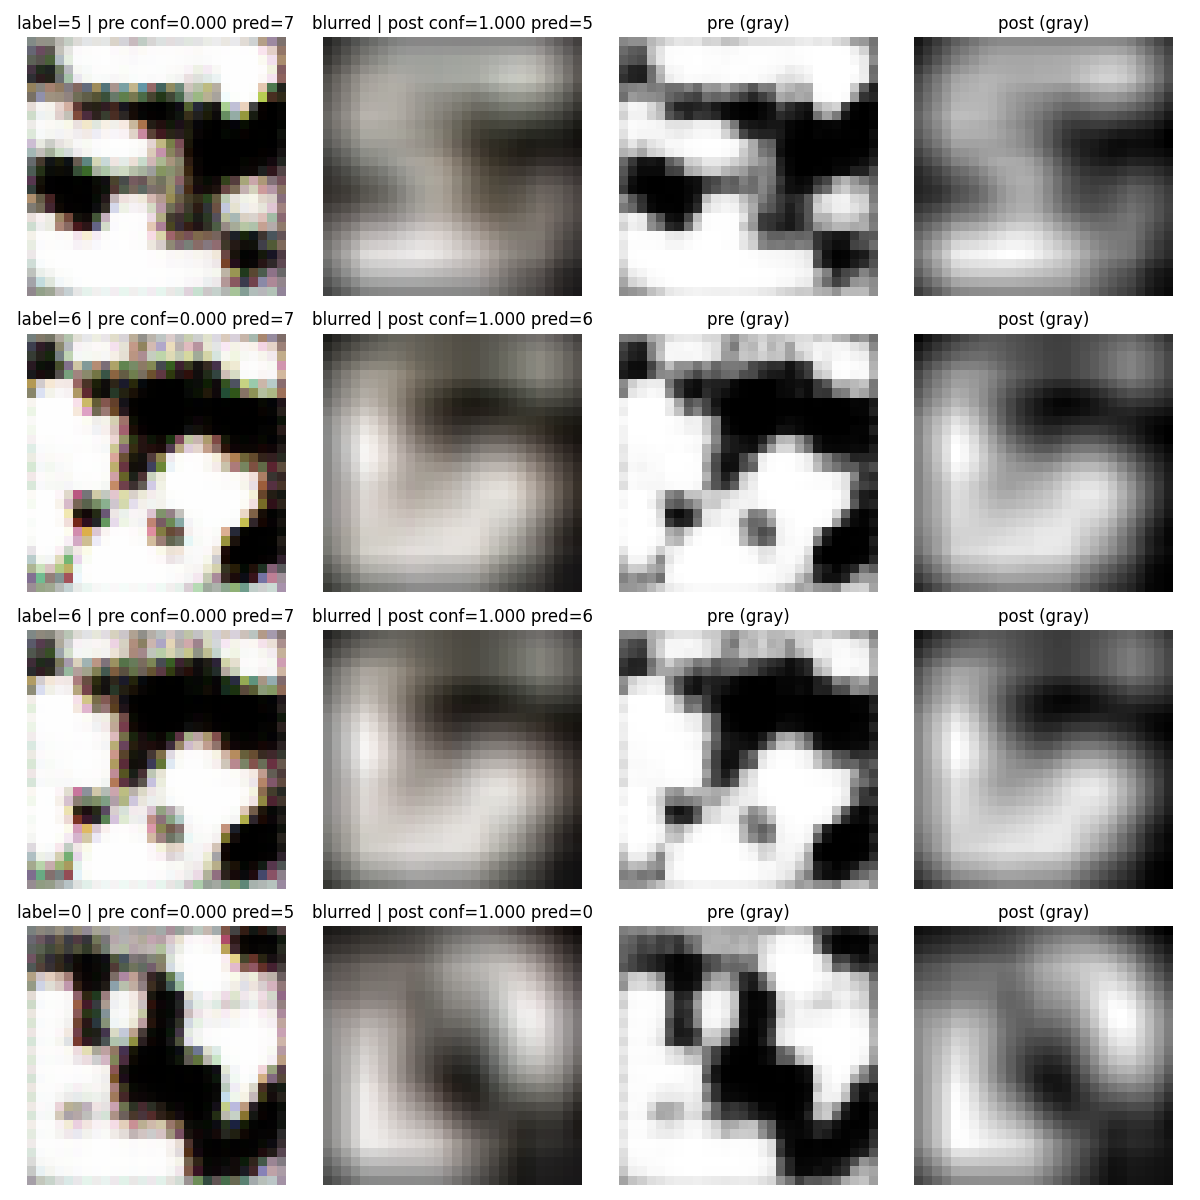

In [20]:
def show_generated(model, n=4, device=device):
    model.eval()
    fig, axes = plt.subplots(n, 3, figsize=(9, n*3))
    
    with torch.no_grad():
        for row in range(n):
            label  = torch.randint(0, 10, (1,)).to(device)
            noise  = torch.randn(1, 2).to(device)
            onehot = F.one_hot(label, num_classes=10).float()
            x      = torch.cat([onehot, noise], dim=1)
            
            generated = model(x)
            blurred   = box_blur(generated)
            
            axes[row, 0].imshow(generated.squeeze(0).cpu().permute(1,2,0))
            axes[row, 0].set_title(f"generated (label={label.item()})")
            axes[row, 1].imshow(blurred.squeeze(0).cpu().permute(1,2,0))
            axes[row, 1].set_title("blurred")
            axes[row, 2].imshow(blurred.squeeze(0).cpu().permute(1,2,0).mean(dim=-1), cmap="gray")
            axes[row, 2].set_title("blurred (gray)")
            for ax in axes[row]: ax.axis("off")
    
    plt.tight_layout()
    plt.savefig("Results/EX04_generated.png")
    plt.close()
    
    from IPython.display import Image as IPImage, display
    display(IPImage("Results/EX04_generated.png"))

show_generated(model_4a)

# part b - trying to resolve degeneracy

In [9]:
# do different labels produce different outputs?
for label in range(10):
    l = torch.tensor([label]).to(device)
    noise = torch.zeros(1, 2).to(device)  # fix noise to isolate label effect
    onehot = F.one_hot(l, num_classes=10).float()
    x = torch.cat([onehot, noise], dim=1)
    out = model_4a(x)
    print(f"label {label} | mean pixel: {out.mean().item():.4f} | max: {out.max().item():.4f}")

label 0 | mean pixel: 0.5853 | max: 0.9995
label 1 | mean pixel: 0.5485 | max: 1.0000
label 2 | mean pixel: 0.5599 | max: 0.9998
label 3 | mean pixel: 0.5817 | max: 0.9998
label 4 | mean pixel: 0.5933 | max: 0.9998
label 5 | mean pixel: 0.6642 | max: 0.9999
label 6 | mean pixel: 0.6688 | max: 0.9999
label 7 | mean pixel: 0.5388 | max: 1.0000
label 8 | mean pixel: 0.5839 | max: 0.9997
label 9 | mean pixel: 0.4936 | max: 1.0000


In [14]:
    
def ex04b_loss_fn(batch, model, mode="train", **kwargs):
    # b, i, label, b_idx, i_idx = batch
    comp, label = batch
    noise   = torch.randn(label.shape[0], 2).to(device)
    onehot  = F.one_hot(label, num_classes=10).float()
    x       = torch.cat([onehot, noise], dim=1)
    generated = model(x)
    conf_pre, pred_pre  = m_classify_3d_with_conf(generated, label)
    blurred   = box_blur(generated)
    conf_post, pred_post = m_classify_3d_with_conf(blurred, label)

    delta_vis = (config.variants.a.alpha * conf_pre) + (config.variants.a.beta * conf_post)
    delta_vis = (-delta_vis).mean() if delta_vis.dim() > 0 else -delta_vis
    loss = delta_vis 
    if mode == "val":
        return {
            "val_loss":  loss.item(),
            "conf_pre":  conf_pre.mean().item(),
            "conf_post": conf_post.mean().item(),
            "delta_vis": delta_vis.mean().item()
        }
    return loss





# ── RUN ───────────────────────────────────────────────────────────────────────
ex04b_info = {
    "exp_id":      "EX_04b",
    "epochs":      10,
    "log_to":      "both", #"file" if you dont want wandb 
    "weights_dir": "Model/B",
    "log_dir":     "logs/B",
    "seed":        42,
    "notes": config.variants.b.description
}

model_4b = singleBlock0cBlurredGenerator()
optimizer = torch.optim.Adam(model_4b.parameters(), lr=config.lr)

b_model = LeNet3channel().to(device)
b_model.load_state_dict(torch.load('../EX_01/Model/B/EX_01b_final.pt', map_location=device, weights_only=True))
b_model.eval()


LeNet3channel(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [15]:
run_experiment(
    model=model_4b,
    optimizer=optimizer,
    loss_fn=ex04b_loss_fn,
    train_loader=ex02a_trainloader,
    val_loader=ex02a_valloader,
    config=ex04b_info,
    log_to=ex04b_info["log_to"],
)

[device] using cuda


conf_post,▁▆▇▇██████
conf_pre,█▄▂▂▁▁▁▁▁▁
delta_vis,█▃▂▂▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▁▁▁▁▁▁▁▁▁
val_loss,█▃▂▂▁▁▁▁▁▁
conf_post,1.0
conf_pre,0.0
delta_vis,-0.45
epoch,10
train_loss,-0.45


singleBlock0cBlurredGenerator(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1568, bias=True)
    (3): ReLU()
    (4): Unflatten(dim=1, unflattened_size=(32, 7, 7))
    (5): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): ReLU()
    (7): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (8): Sigmoid()
  )
)

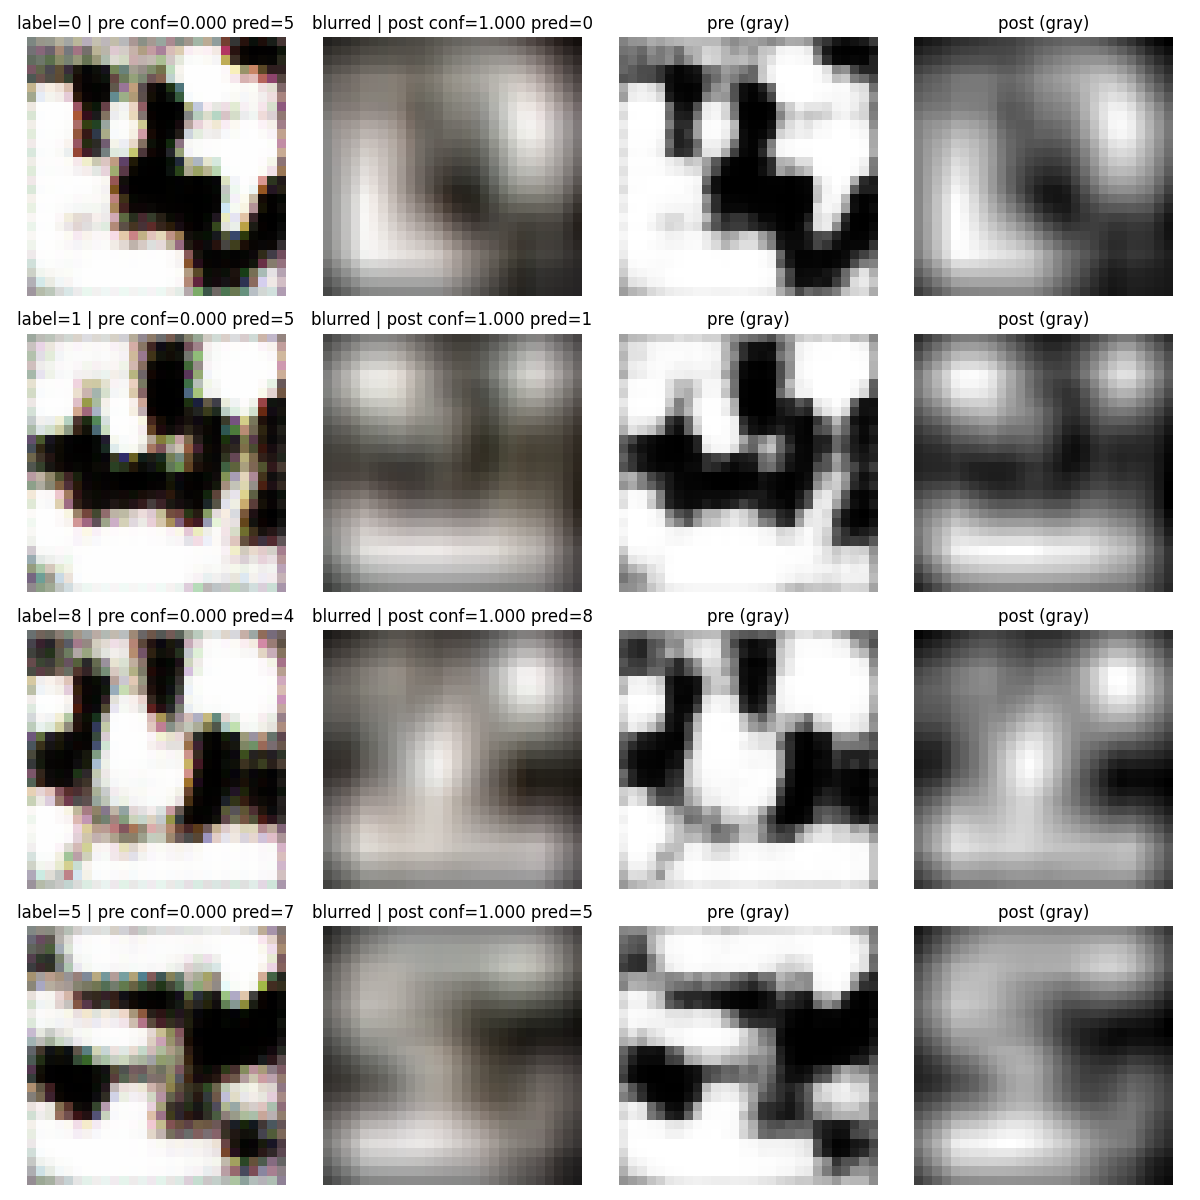

In [21]:
def show_generated(model, n=4, device=device):
    model.eval()
    fig, axes = plt.subplots(n, 4, figsize=(12, n*3))
    
    with torch.no_grad():
        for row in range(n):
            label  = torch.randint(0, 10, (1,)).to(device)
            noise  = torch.randn(1, 2).to(device)
            onehot = F.one_hot(label, num_classes=10).float()
            x      = torch.cat([onehot, noise], dim=1)
            
            generated = model(x)
            blurred   = box_blur(generated)
            
            conf_pre,  pred_pre  = m_classify_3d_with_conf(generated, label)
            conf_post, pred_post = m_classify_3d_with_conf(blurred,   label)

            axes[row, 0].imshow(generated.squeeze(0).cpu().permute(1,2,0))
            axes[row, 0].set_title(f"label={label.item()} | pre conf={conf_pre.item():.3f} pred={pred_pre.item()}")
            axes[row, 1].imshow(blurred.squeeze(0).cpu().permute(1,2,0))
            axes[row, 1].set_title(f"blurred | post conf={conf_post.item():.3f} pred={pred_post.item()}")
            axes[row, 2].imshow(generated.squeeze(0).cpu().permute(1,2,0).mean(dim=-1), cmap="gray")
            axes[row, 2].set_title("pre (gray)")
            axes[row, 3].imshow(blurred.squeeze(0).cpu().permute(1,2,0).mean(dim=-1), cmap="gray")
            axes[row, 3].set_title("post (gray)")
            for ax in axes[row]: ax.axis("off")
    
    plt.tight_layout()
    plt.savefig("Results/EX04_generated.png")
    plt.close()
    
    from IPython.display import Image as IPImage, display
    display(IPImage("Results/EX04_generated.png"))

show_generated(model_4b)

# part c - trying MSE loss for post
the idea here is that the blurred image shouldn't be able to trick the classifier - we'll just put MSE loss to the actual character (plus a little bit of blur). we want the blurred version to be the character, and we'll just use the classifer to make sure pre has some constraints on it. 

In [53]:
    
def ex04c_loss_fn(batch, model, mode="train", **kwargs):
    # b, i, label, b_idx, i_idx = batch
    comp, label = batch
    b, i  = comp[:, :3], comp[:, 3:]
    noise   = torch.randn(label.shape[0], 2).to(device)
    onehot  = F.one_hot(label, num_classes=10).float()
    x       = torch.cat([onehot, noise], dim=1)
    generated = model(x)
    conf_pre, pred_pre  = m_classify_3d_with_conf(generated, label)
    generated_1d = generated.mean(dim=1, keepdim=True) 
    blurred_real = box_blur(i, kernel_size=3) #no-op
    blurred_gen  = box_blur(generated_1d)

    post_loss    = F.mse_loss(blurred_gen, blurred_real)

    delta_vis = (config.variants.c.alpha * conf_pre) + (config.variants.c.beta * post_loss)
    delta_vis = (-delta_vis).mean() if delta_vis.dim() > 0 else -delta_vis
    loss = delta_vis 
    if mode == "val":
        return {
            "val_loss":  loss.item(),
            "conf_pre":  conf_pre.mean().item(),
            "post_loss": post_loss.item(),
            "delta_vis": delta_vis.mean().item()
        }
    return loss





# ── RUN ───────────────────────────────────────────────────────────────────────
ex04c_info = {
    "exp_id":      "EX_04c",
    "epochs":      3,
    "log_to":      "both", #"file" if you dont want wandb 
    "weights_dir": "Model/C",
    "log_dir":     "logs/C",
    "seed":        42,
    "notes": config.variants.c.description
}

model_4c = singleBlock0cBlurredGenerator()
optimizer = torch.optim.Adam(model_4c.parameters(), lr=config.lr)

b_model = LeNet3channel().to(device)
b_model.load_state_dict(torch.load('../EX_01/Model/B/EX_01b_final.pt', map_location=device, weights_only=True))
b_model.eval()





n = 10000 #len(ex02a_trainset)
train_size = int(0.9 * n)
val_size   = n - train_size

subset = torch.utils.data.Subset(ex02a_trainset, random.sample(range(len(ex02a_trainset)), n))
train_set, val_set = random_split(subset, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(config.seed))

ex04c_trainloader = DataLoader(train_set, batch_size=config.batch_size, shuffle=True)
ex04c_valloader   = DataLoader(val_set,   batch_size=config.batch_size)


In [54]:
run_experiment(
    model=model_4c,
    optimizer=optimizer,
    loss_fn=ex04c_loss_fn,
    train_loader=ex02a_trainloader,
    val_loader=ex02a_trainloader,
    config=ex04c_info,
    log_to=ex04c_info["log_to"],
)

[device] using cuda


conf_pre,█▆▁
delta_vis,█▃▁
epoch,▁▅█
post_loss,█▃▁
train_loss,█▁▁
val_loss,█▃▁
conf_pre,2e-05
delta_vis,0.01477
epoch,3
post_loss,0.0328
train_loss,0.01479


singleBlock0cBlurredGenerator(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1568, bias=True)
    (3): ReLU()
    (4): Unflatten(dim=1, unflattened_size=(32, 7, 7))
    (5): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): ReLU()
    (7): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (8): Sigmoid()
  )
)

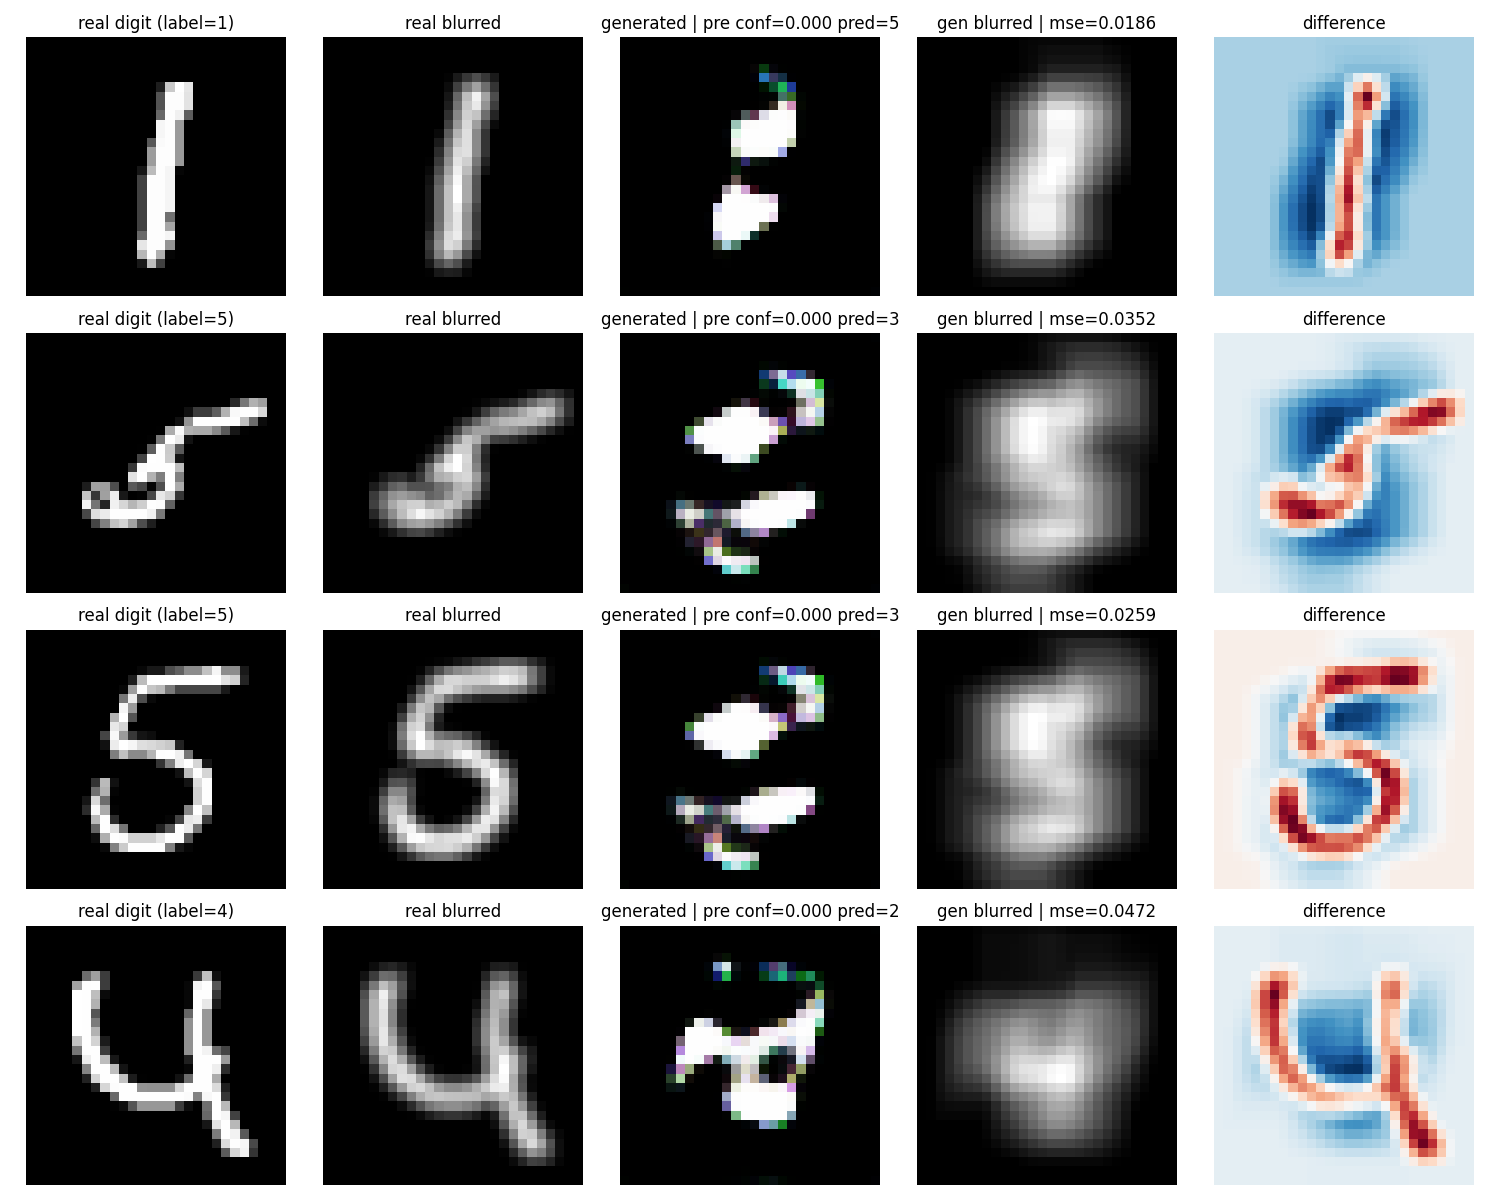

In [56]:
def show_generated(model, dataset, n=4, device=device):
    model.eval()
    fig, axes = plt.subplots(n, 5, figsize=(15, n*3))
    
    with torch.no_grad():
        for row in range(n):
            comp, label_int = dataset[random.randint(0, len(dataset)-1)]
            label  = torch.tensor([label_int]).to(device)
            i      = comp[3:].unsqueeze(0).to(device)  # real digit (1, 1, 28, 28)
            
            noise   = torch.randn(1, 2).to(device)
            onehot  = F.one_hot(label, num_classes=10).float()
            x       = torch.cat([onehot, noise], dim=1)
            
            generated    = model(x)
            generated_1d = generated.mean(dim=1, keepdim=True)
            blurred_gen  = box_blur(generated_1d)
            blurred_real = box_blur(i, kernel_size=3) #no-op
            post_loss    = F.mse_loss(blurred_gen, blurred_real).item()
            
            conf_pre, pred_pre = m_classify_3d_with_conf(generated, label)

            axes[row, 0].imshow(i.squeeze().cpu(), cmap="gray")
            axes[row, 0].set_title(f"real digit (label={label_int})")
            axes[row, 1].imshow(blurred_real.squeeze().cpu(), cmap="gray")
            axes[row, 1].set_title("real blurred")
            axes[row, 2].imshow(generated.squeeze(0).cpu().permute(1,2,0))
            axes[row, 2].set_title(f"generated | pre conf={conf_pre.item():.3f} pred={pred_pre.item()}")
            axes[row, 3].imshow(blurred_gen.squeeze().cpu(), cmap="gray")
            axes[row, 3].set_title(f"gen blurred | mse={post_loss:.4f}")
            axes[row, 4].imshow((blurred_gen - blurred_real).squeeze().cpu(), cmap="RdBu")
            axes[row, 4].set_title("difference")
            for ax in axes[row]: ax.axis("off")
    
    plt.tight_layout()
    plt.savefig("Results/EX04_generated.png")
    plt.close()
    
    from IPython.display import Image as IPImage, display
    display(IPImage("Results/EX04_generated.png"))

show_generated(model_4c, train_set)